## Setup

In [ ]:
from evaluation.plot_style import apply_plot_style
from models.llm.common import METRICS_DIR
from evaluation.llm.helpers import (
    load_metrics_from_dir,
    plot_model_metrics_combined_scatter,
)

apply_plot_style()

## Load Configs

In [ ]:
df_metrics, items, config_names = load_metrics_from_dir(METRICS_DIR)

## Model Selection

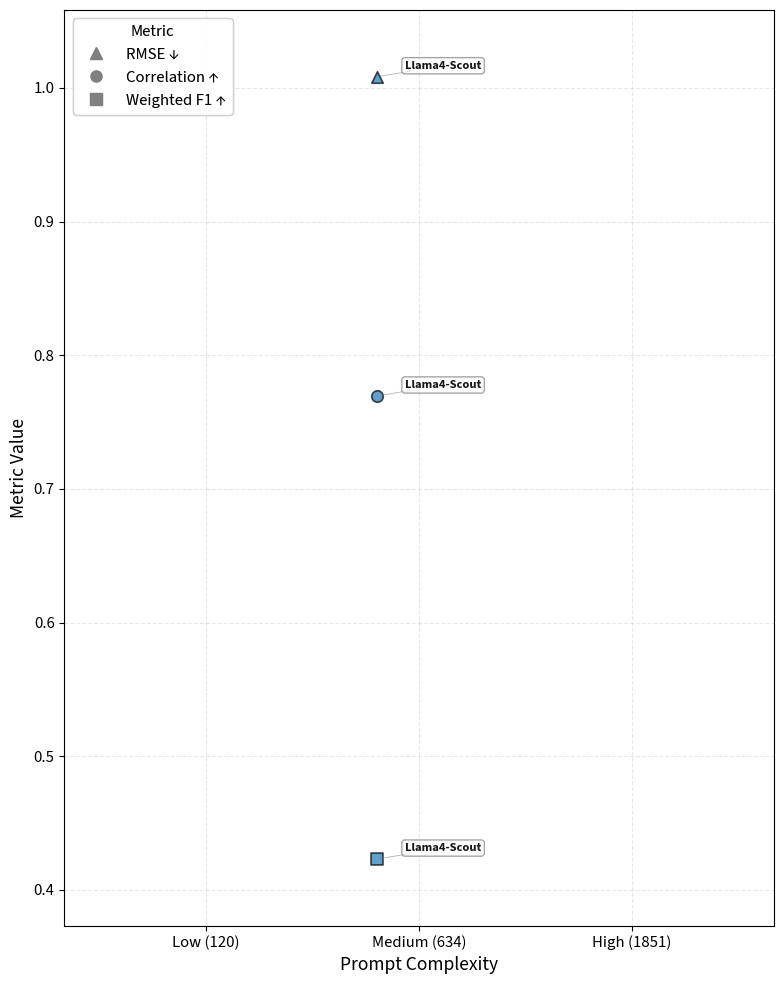

In [ ]:
plot_model_metrics_combined_scatter(
    df=df_metrics,
    min_threshold=0.1,
    y_padding=0.05,
    figsize=(8, 10),
    shorten_model_names=True,
    show_labels=True,
)

### Model Summary

In [ ]:
summary_table = df_metrics.pivot_table(
    index="model_name",
    columns="prompt",
    values=["correlation", "rmse", "accuracy", "throughput", "error_rate"],
    aggfunc="first",
)

print("Correlation Summary:")
print("=" * 80)
print(summary_table["correlation"].round(3))

print("\n\nRMSE Summary:")
print("=" * 80)
print(summary_table["rmse"].round(3))

print("\n\nAccuracy Summary:")
print("=" * 80)
print(summary_table["accuracy"].round(3))

print("\n\nThroughput Summary (predictions/sec):")
print("=" * 80)
print(summary_table["throughput"].round(3))

print("\n\nError Rate Summary (%):")
print("=" * 80)
print(summary_table["error_rate"].round(1))

Correlation Summary:
prompt            On a scale of 0-5, rate how well this text allows a reader to visualize the scene, objects, or characters described: 0=not visualizable, 1=simple object/person, 2=recognizable place/basic character, 3=basic scene/detailed face, 4=full scene with details, 5=vivid complete scene.\n\n## Examples\nHere are examples demonstrating each rating level:\n\n<example_1>\n<text_segment>If not, please say so. The alternative is in the hands of the Crown. I am the Crown. The Crown may at any time confiscate property and banish malcontents and disturbers.</text_segment>\n{\n  "rating": 0\n}\n</example_1>\n\n<example_2>\n<text_segment>By this time the fresh new fool's cap made from yesterday's "Bee" would have been pinned on her head. "Quelle injustice! Quelle injustice!" This last apostrophe in a high, whining nasal voice, always procured Pupasse's elevation on the tall three-legged stool in the corner.</text_segment>\n{\n  "rating": 1\n}\n</example_2>\n\n<exampl

### Overall Model Ranking

In [ ]:
overall_ranking = (
    df_metrics.groupby("model_name")
    .agg(
        {
            "correlation": "mean",
            "rmse": "mean",
            "accuracy": "mean",
            "throughput": "mean",
            "error_rate": "mean",
        }
    )
    .round(3)
    .sort_values("correlation", ascending=False)
)

print("\nOverall Model Rankings (Average across all prompts):")
print("=" * 80)
print(overall_ranking)


Overall Model Rankings (Average across all prompts):
                  correlation   rmse  accuracy  throughput  error_rate
model_name                                                            
Llama4-Scout-17b        0.777  0.973     0.469       4.678         0.0
